# 01 — Auditoria da base SINASC

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import pyarrow.parquet as pq
import seaborn as sns

RAW = Path("../data/raw")
FILES = sorted(RAW.glob("sinasc_ba_*.parquet"))

PARTO_LABELS = {
    "1": "Vaginal",
    "2": "Cesárea",
    "9": "Ignorado",
}

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

FILES

[PosixPath('../data/raw/sinasc_ba_2022.parquet'),
 PosixPath('../data/raw/sinasc_ba_2023.parquet'),
 PosixPath('../data/raw/sinasc_ba_2024.parquet')]

## Step 1 — Inventário

**Pergunta:** o que temos na mão?

- Quantos arquivos / anos
- Linhas e colunas por ano
- Schema idêntico entre anos?

**Decisão esperada:** confirmar que dá para empilhar os parquets sem surpresa de coluna.

In [2]:
rows = []
schemas = {}

for path in FILES:
    year = path.stem.split("_")[-1]
    schema_cols = pq.read_schema(path).names
    n_rows = pq.read_metadata(path).num_rows

    rows.append({
        "ano": year,
        "arquivo": path.name,
        "linhas": n_rows,
        "colunas": len(schema_cols),
    })
    schemas[year] = set(schema_cols)

inv = pd.DataFrame(rows).sort_values("ano")
inv

,ano,arquivo,linhas,colunas
0,2022,sinasc_ba_2022.parquet,173824,61
1,2023,sinasc_ba_2023.parquet,170314,61
2,2024,sinasc_ba_2024.parquet,160002,61


In [3]:
years = sorted(schemas)
ref = schemas[years[0]]

schema_ok = all(schemas[y] == ref for y in years)
only_in_first = sorted(ref - schemas[years[-1]]) if len(years) > 1 else []
only_in_last = sorted(schemas[years[-1]] - ref) if len(years) > 1 else []

print(f"Anos encontrados: {', '.join(years)}")
print(f"Total de linhas: {inv['linhas'].sum():,}".replace(",", "."))
print(f"Colunas por arquivo: {inv['colunas'].unique().tolist()}")
print(f"Schema idêntico entre anos? {'✅ sim' if schema_ok else '❌ não'}")
if only_in_first:
    print("Só no primeiro ano:", only_in_first)
if only_in_last:
    print("Só no último ano:", only_in_last)

Anos encontrados: 2022, 2023, 2024
Total de linhas: 504.140
Colunas por arquivo: [61]
Schema idêntico entre anos? ✅ sim


## Step 2 — Alvo (`PARTO`)

**Pergunta:** dá para classificar cesárea vs parto vaginal?

| Código | Significado |
|--------|-------------|
| `1` | Vaginal |
| `2` | Cesárea |
| `9` | Ignorado → **dropar linha** |

**Decisão esperada:**
- quanto % de linhas válidas restam
- quão desbalanceadas estão as classes (impacto em F1 / stratify)

In [4]:
parto_frames = []

for path in FILES:
    year = path.stem.split("_")[-1]
    s = pd.read_parquet(path, columns=["PARTO"])["PARTO"].astype(str).str.strip()
    tab = s.value_counts(dropna=False).reset_index()
    tab.columns = ["PARTO", "n"]
    tab["ano"] = year
    tab["PARTO"] = tab["PARTO"].astype(str)
    tab["classe"] = tab["PARTO"].map(PARTO_LABELS).fillna("Outro/NA")
    parto_frames.append(tab)

parto_long = pd.concat(parto_frames, ignore_index=True)
parto_long

,PARTO,n,ano,classe
0,1,90536,2022,Vaginal
1,2,83141,2022,Cesárea
2,,131,2022,Outro/NA
3,9,16,2022,Ignorado
4,1,85189,2023,Vaginal
5,2,85003,2023,Cesárea
6,,114,2023,Outro/NA
7,9,8,2023,Ignorado
8,2,84174,2024,Cesárea
9,1,75742,2024,Vaginal


In [5]:
summary_rows = []

for path in FILES:
    year = path.stem.split("_")[-1]
    s = pd.read_parquet(path, columns=["PARTO"])["PARTO"].astype(str).str.strip()
    total = len(s)
    valid = s.isin(["1", "2"]).sum()
    ignorado = (s == "9").sum()
    vaginal = (s == "1").sum()
    cesarea = (s == "2").sum()
    outros = total - valid - ignorado

    summary_rows.append({
        "ano": year,
        "total": total,
        "validas (1+2)": valid,
        "% validas": round(100 * valid / total, 2),
        "vaginal (1)": vaginal,
        "cesarea (2)": cesarea,
        "% cesarea (sobre validas)": round(100 * cesarea / valid, 2) if valid else None,
        "ignorado (9)": ignorado,
        "% ignorado": round(100 * ignorado / total, 2),
        "outros": outros,
    })

parto_summary = pd.DataFrame(summary_rows).sort_values("ano")
parto_summary

,ano,total,validas (1+2),% validas,vaginal (1),cesarea (2),% cesarea (sobre validas),ignorado (9),% ignorado,outros
0,2022,173824,173677,99.92,90536,83141,47.87,16,0.01,131
1,2023,170314,170192,99.93,85189,85003,49.95,8,0.00,114
2,2024,160002,159916,99.95,75742,84174,52.64,5,0.00,81


/var/folders/h2/5gt3rzvn5db84d4ds6tjbrfm0000gn/T/ipykernel_28134/3468991605.py:31: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  plot_df.pivot_table(index="ano", columns="classe", values="n", aggfunc="sum", fill_value=0)


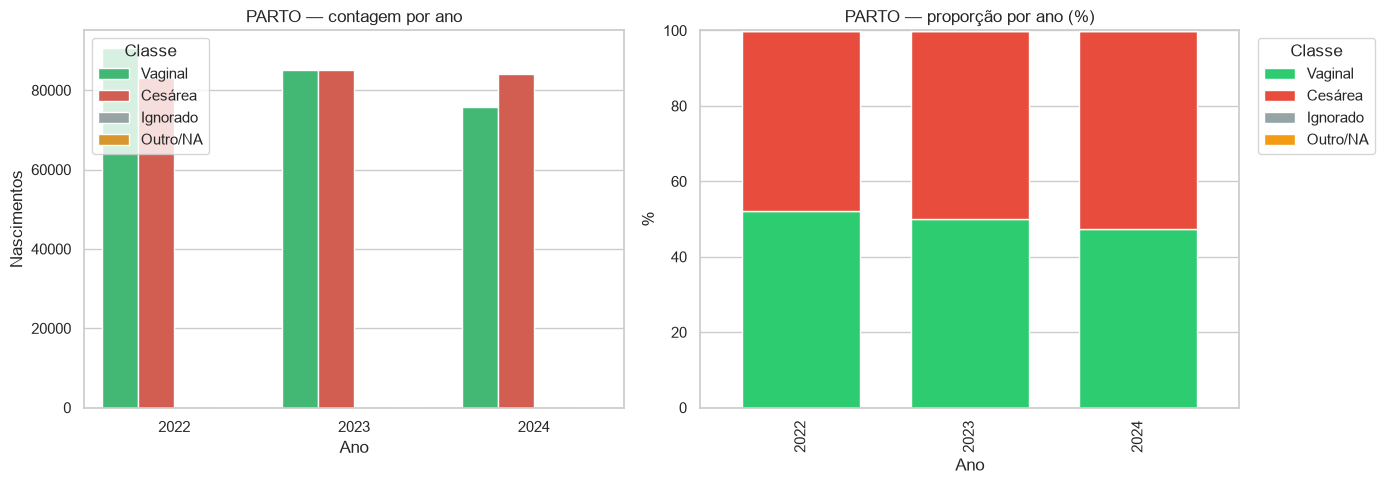

In [6]:
ORDER = ["Vaginal", "Cesárea", "Ignorado", "Outro/NA"]
COLORS = {
    "Vaginal": "#2ecc71",
    "Cesárea": "#e74c3c",
    "Ignorado": "#95a5a6",
    "Outro/NA": "#f39c12",
}

plot_df = parto_long.copy()
plot_df["classe"] = pd.Categorical(plot_df["classe"], categories=ORDER, ordered=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Esquerda: contagem absoluta por ano
sns.barplot(
    data=plot_df,
    x="ano",
    y="n",
    hue="classe",
    hue_order=ORDER,
    palette=COLORS,
    ax=axes[0],
)
axes[0].set_title("PARTO — contagem por ano")
axes[0].set_xlabel("Ano")
axes[0].set_ylabel("Nascimentos")
axes[0].legend(title="Classe", loc="upper left")

# Direita: proporção 100% (balanceamento visual)
prop = (
    plot_df.pivot_table(index="ano", columns="classe", values="n", aggfunc="sum", fill_value=0)
    .reindex(columns=ORDER, fill_value=0)
)
prop_pct = prop.div(prop.sum(axis=1), axis=0) * 100

prop_pct.plot(
    kind="bar",
    stacked=True,
    color=[COLORS[c] for c in ORDER],
    ax=axes[1],
    width=0.7,
)
axes[1].set_title("PARTO — proporção por ano (%)")
axes[1].set_xlabel("Ano")
axes[1].set_ylabel("%")
axes[1].legend(title="Classe", bbox_to_anchor=(1.02, 1), loc="upper left")
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.show()

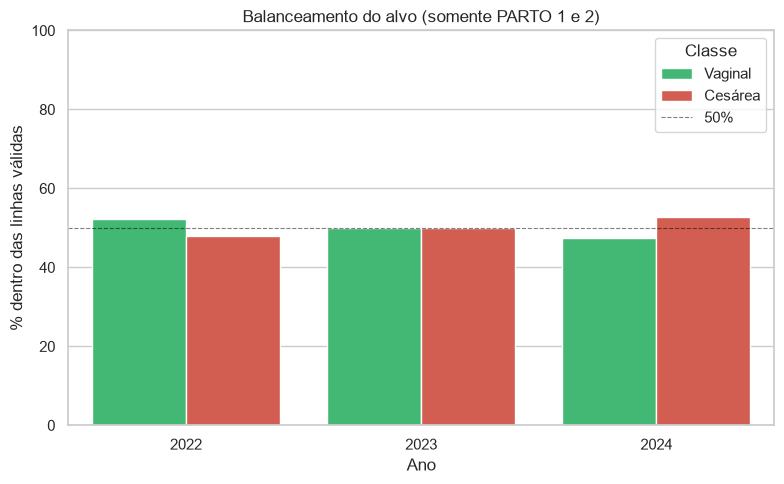

classe,Cesárea,Vaginal
ano,,
2022,47.9,52.1
2023,49.9,50.1
2024,52.6,47.4


In [7]:
# Só classes válidas (1 e 2): cesárea vs vaginal
valid_long = parto_long[parto_long["PARTO"].isin(["1", "2"])].copy()
valid_totals = valid_long.groupby("ano", as_index=False)["n"].sum().rename(columns={"n": "total_valido"})
valid_long = valid_long.merge(valid_totals, on="ano")
valid_long["pct"] = 100 * valid_long["n"] / valid_long["total_valido"]

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=valid_long,
    x="ano",
    y="pct",
    hue="classe",
    hue_order=["Vaginal", "Cesárea"],
    palette={"Vaginal": COLORS["Vaginal"], "Cesárea": COLORS["Cesárea"]},
    ax=ax,
)
ax.axhline(50, color="black", linestyle="--", linewidth=0.8, alpha=0.5, label="50%")
ax.set_title("Balanceamento do alvo (somente PARTO 1 e 2)")
ax.set_xlabel("Ano")
ax.set_ylabel("% dentro das linhas válidas")
ax.set_ylim(0, 100)
ax.legend(title="Classe")
plt.tight_layout()
plt.show()

valid_long.pivot(index="ano", columns="classe", values="pct").round(1)

### Step 2 — conclusão

Preencha após rodar:

| Regra | Valor |
|-------|-------|
| Dropar linhas | `PARTO == 9` (e outros códigos inválidos) |
| Alvo binário | `y = 1` se cesárea (`PARTO == 2`) |
| Balanceamento | cesárea ~___% · vaginal ~___% |
| Stratify no split? | sim / não — justificar |

**Próximo step (3):** qualidade coluna a coluna (missing, ignorado, cardinalidade).